In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [28]:
medical_df = pd.read_csv('insurance.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [29]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [30]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [31]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['figure.facecolor'] = '#000000'

In [32]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [33]:
fig = px.histogram(
    medical_df,
    x='age',
    nbins=47,
    title='Distribution of Age',
    marginal='box'
)
fig.update_layout(bargap=0.1)

In [34]:
fig_2 = px.histogram(
    medical_df,
    x='bmi',
    marginal='box',
    title='Distribution of BMI'
)
fig_2.update_layout(bargap=0.1)

In [35]:
fig_3 = px.histogram(
    medical_df,
    x='charges',
    color='smoker',
    title='Annual Charges',
    marginal='box'
)
fig_3.update_layout(bargap=0.1)

In [36]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [37]:
px.histogram(medical_df, x='smoker', color='sex', title='Smokers')

In [38]:
fig_4 = px.scatter(
    medical_df,
    x='age',
    y='charges',
    color='smoker',
    title='Age vs. Smoker',
    hover_data=['sex'],
    opacity=0.8,
)
fig_4.update_layout(bargap=0.1)
fig_4.update_traces(marker_size=5)

In [39]:
fig_5 = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    opacity=0.8,
    hover_data=['sex'],
    title='BMI vs Charges'
)
fig_5.update_traces(marker_size=5)

In [40]:
# scatter vs violin
px.scatter(medical_df, x='children', y='charges')

In [41]:
px.violin(medical_df, x='children',y='charges')

In [42]:
# correlation between charges and age
medical_df.charges.corr(medical_df.age)

np.float64(0.29900819333064754)

In [43]:
# correlation between charges and bmi
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362884)

In [44]:
# correlation between charges and children
medical_df.charges.corr(medical_df.children)

np.float64(0.0679982268479048)

In [45]:
# trying to correlate charges and smoker
medical_df.charges.corr(medical_df.smoker)

ValueError: could not convert string to float: 'yes'

In [46]:
smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [47]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

Text(0.5, 1.0, 'Correlation Matrix')

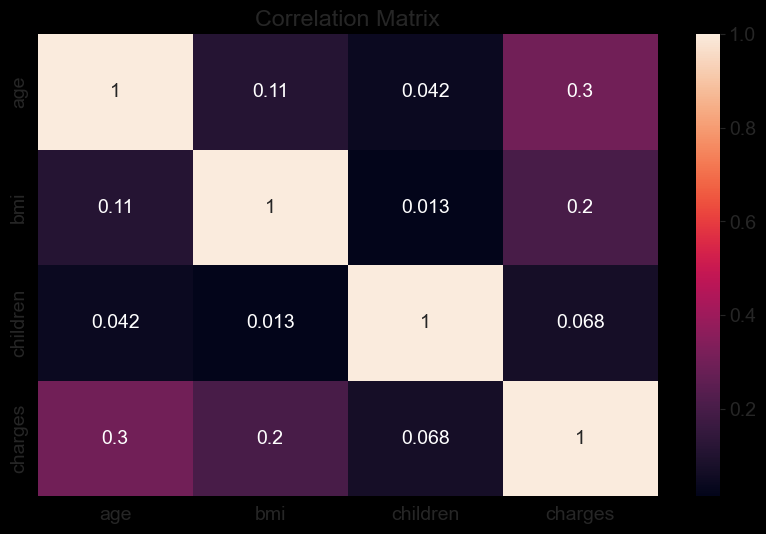

In [48]:
sns.heatmap(medical_df.drop(columns=['sex', 'smoker', 'region']).corr(), annot=True)
plt.title('Correlation Matrix')

<Axes: xlabel='age', ylabel='charges'>

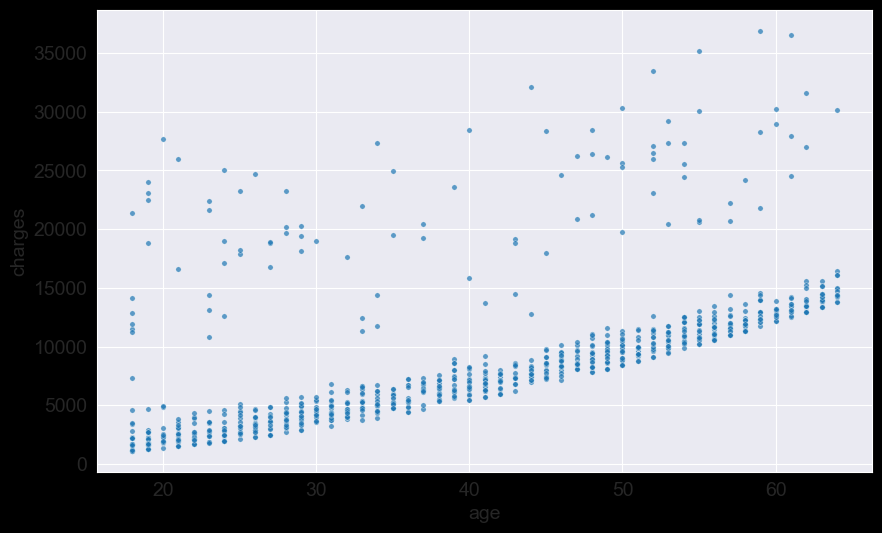

In [49]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
sns.scatterplot(data=non_smoker_df, x='age', y='charges', s=15, alpha=0.7)

In [50]:
def estimate_charges(a, w, b):
    return w*a+b

In [51]:
w=50
b=100

In [52]:
estimate_charges(30, w, b)

1600

In [53]:
ages=non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [54]:
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [55]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

Text(0, 0.5, 'Estimated Charges:')

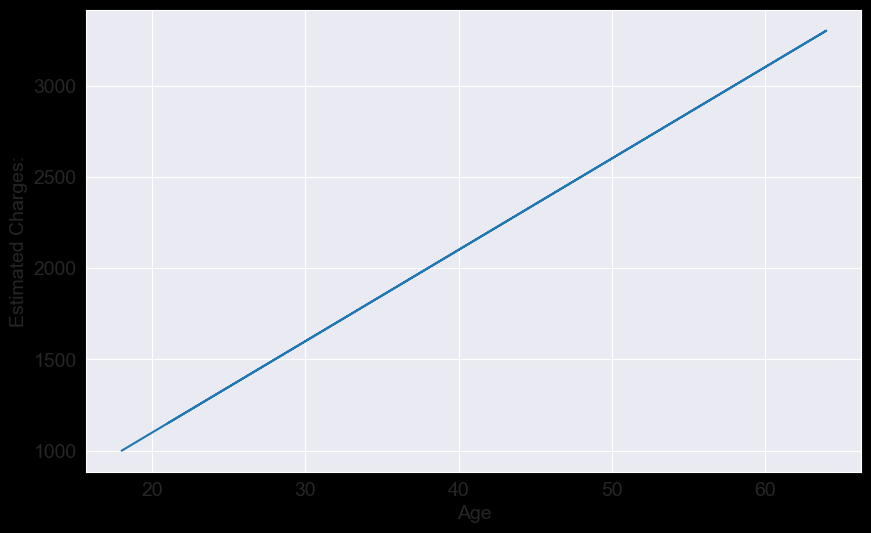

In [56]:
plt.plot(ages, estimated_charges)
plt.xlabel('Age')
plt.ylabel('Estimated Charges:')

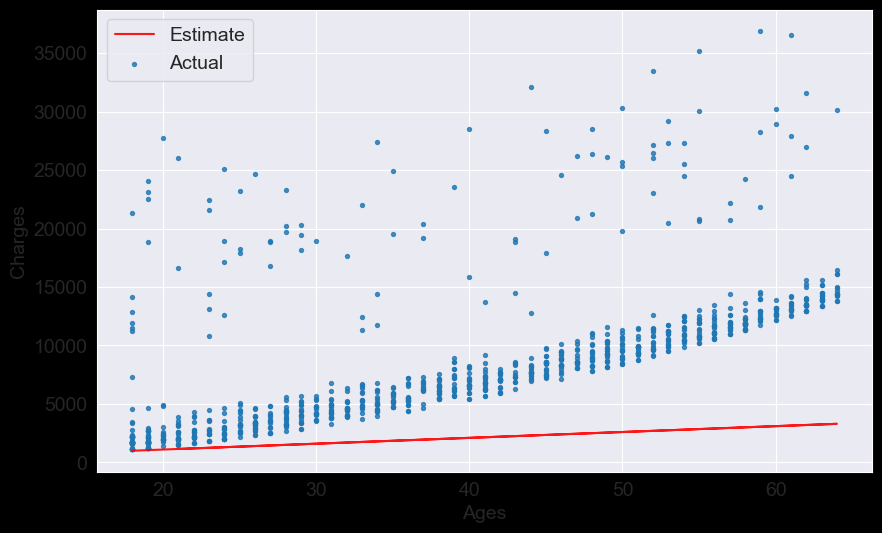

In [57]:
target = non_smoker_df.charges
plt.plot(ages, estimated_charges, alpha=0.9, c='r')
plt.scatter(ages, target, s=8, alpha=0.8)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

In [58]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, alpha=0.9, c='r')
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

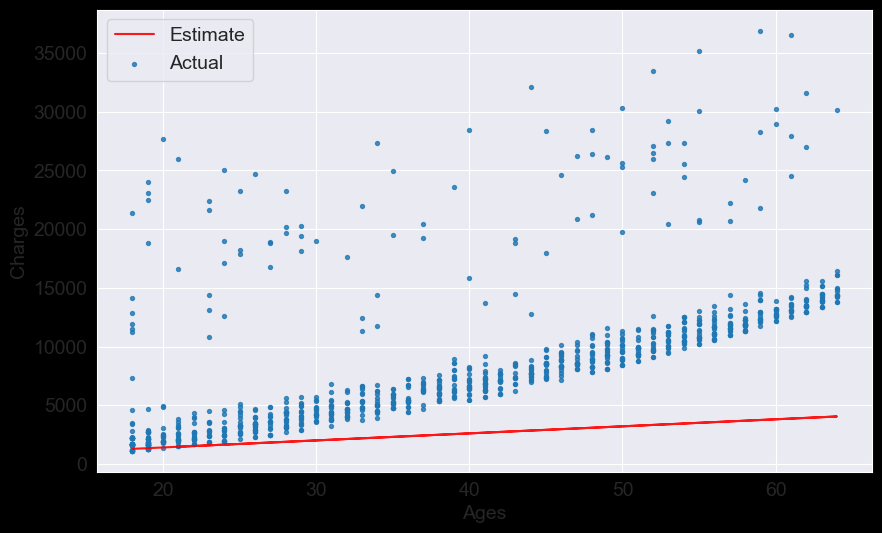

In [59]:
try_parameters(60, 200)

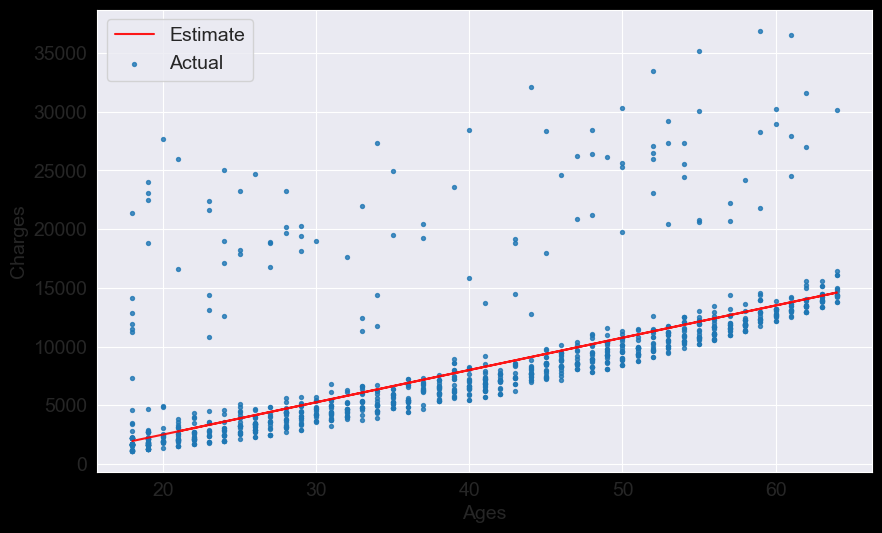

In [60]:
try_parameters(275, -3000)

In [61]:
targets = non_smoker_df.charges
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [62]:
predictions = estimated_charges
predictions

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [63]:
import numpy as np

In [64]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [65]:
w = 50
b = 100

In [66]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [67]:
rmse(targets, predicted)

np.float64(8461.949562575493)

In [68]:
def try_parameters(w,b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predcitions = estimate_charges(ages, w, b)

    plt.plot(ages, predcitions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])

    loss = rmse(target, predcitions)
    print(f'mse={loss}')

mse=4670.521202520753


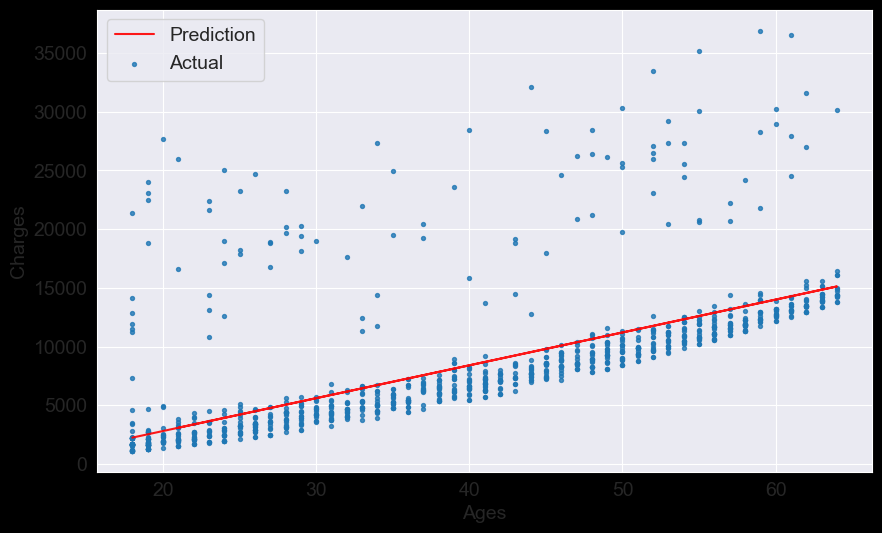

In [69]:
try_parameters(280, -2800)

In [70]:
from sklearn.linear_model import LinearRegression

In [71]:
model = LinearRegression()

In [72]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



In [73]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges

print(f'inputs.shape: {inputs.shape}')
print(f'targets.shape: {targets.shape}')

inputs.shape: (1064, 1)
targets.shape: (1064,)


In [74]:
model.fit(inputs,targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
model.predict(np.array([[23],[37],[61]]))

/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [76]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [77]:
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [78]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [79]:
# w
model.coef_

array([267.24891283])

In [80]:
# b
model.intercept_

np.float64(-2091.4205565650773)

mse=4662.505766636395


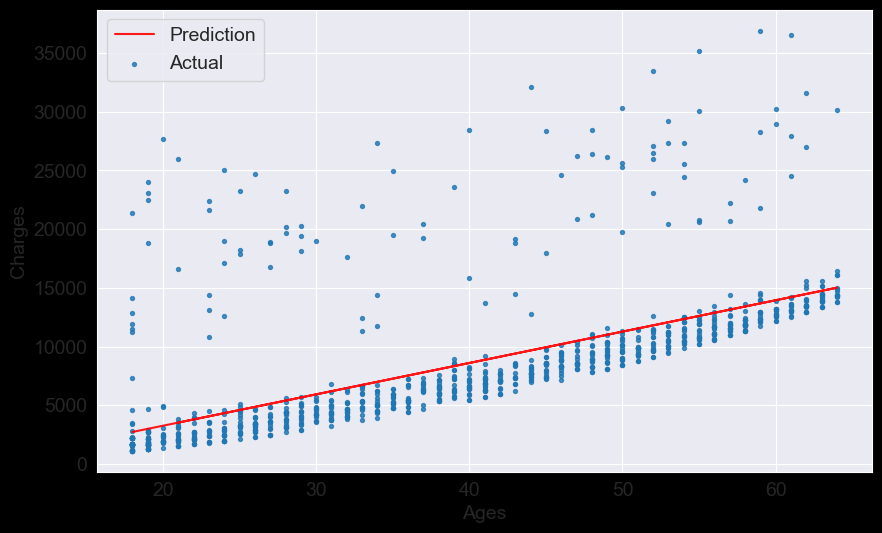

In [81]:
try_parameters(model.coef_, model.intercept_)

In [82]:
from sklearn.linear_model import SGDRegressor
model2 = SGDRegressor()
model2.fit(inputs, targets)
model2.predict(inputs)

array([-3197.54107483,   263.89467927,  1994.61255632, ...,
       -3197.54107483, -3197.54107483, -2159.1103486 ], shape=(1064,))

In [83]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [ ]:
# w
print(model.coef_, model2.coef_)

[267.24891283] [237.22771865]


In [ ]:
# b
print(model.intercept_, model2.intercept_)

-2091.4205565650773 [-297.43320925]


mse=4721.397870815767


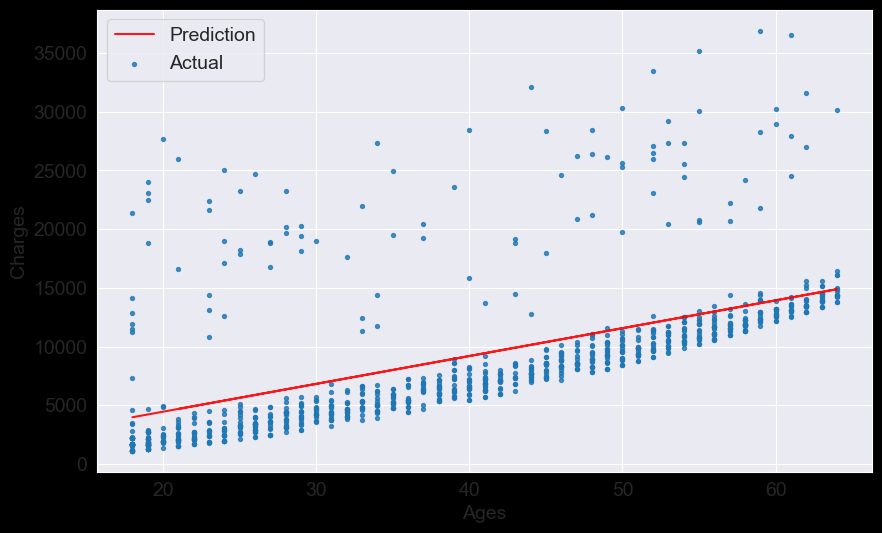

In [ ]:
try_parameters(model2.coef_,model2.intercept_)